In [1]:
import numpy as np
import matplotlib.pyplot as plt

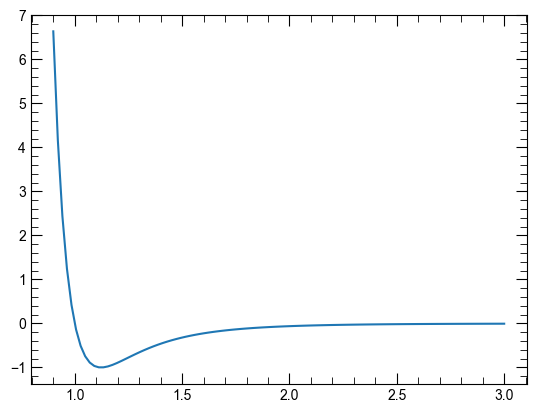

In [2]:
sigma = 1.0
epsilon = 1.0

lj_potential = lambda r: 4 * epsilon * ((sigma / r) ** 12 - (sigma / r) ** 6)

rs = np.linspace(0.9 * sigma, 3.0 * sigma, 100)
vs = lj_potential(rs)
fig, ax = plt.subplots()
ax.plot(rs, vs)

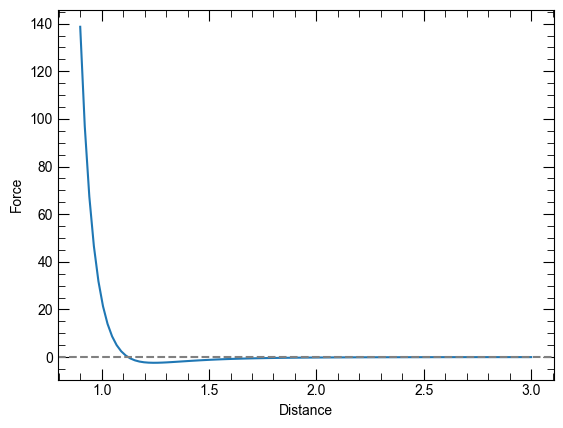

In [3]:
def compute_lj_force(r_vec, sigma, epsilon):
    r = np.linalg.norm(r_vec)
    if r == 0:
        return np.zeros_like(r_vec)
    force_magnitude = 24 * epsilon * (2 * (sigma**12) / (r**13) - (sigma**6) / (r**7))
    force_vector = force_magnitude * (r_vec / r)
    return force_vector


forces = np.array([compute_lj_force(np.array([r, 0]), sigma, epsilon) for r in rs])
fig, ax = plt.subplots()
ax.plot(rs, forces[:, 0])
ax.set_xlabel("Distance")
ax.set_ylabel("Force")
ax.axhline(0, color="gray", linestyle="--")

In [27]:
a = 2 ** (1 / 6) * sigma  # 平衡距離
initial_positions = np.array([0, a + 0.1, 2 * a])
initial_velocities = np.array([0.0, 0.0, 0.0])
masses = np.array([1.0, 1.0, 1.0])
total_time = 10.0
num_steps = 10000
dt = total_time / num_steps
pos_T = np.zeros((num_steps, 3))
pos_T[0] = initial_positions
pos_T[1] = initial_positions + initial_velocities * dt

In [28]:
t = 1
r_vec = pos_T[t, 1] - pos_T[t, 0]
force_on_0 = compute_lj_force(r_vec, sigma, epsilon)
force_on_1 = -force_on_0
print("Force on particle 0 at step", t, ":", force_on_0)
print("Force on particle 1 at step", t, ":", force_on_1)

Force on particle 0 at step 1 : -2.357342349947273
Force on particle 1 at step 1 : 2.357342349947273


In [29]:
num_particles = pos_T.shape[1]
forces_traj = np.zeros((num_steps, num_particles))
for t in range(1, num_steps - 1):
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            r_vec = pos_T[t, i] - pos_T[t, j]
            force_ij = compute_lj_force(r_vec, sigma, epsilon)
            forces_traj[t, i] += force_ij
            forces_traj[t, j] -= force_ij

    for i in range(num_particles):
        acceleration = forces_traj[t, i] / masses[i]
        pos_T[t + 1, i] = 2 * pos_T[t, i] - pos_T[t - 1, i] + acceleration * dt**2

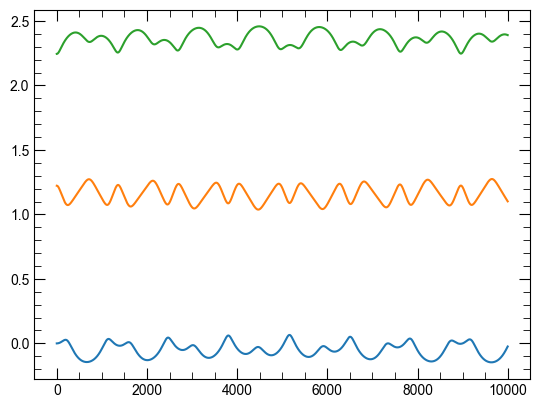

In [30]:
num_particles = pos_T.shape[1]
fig, ax = plt.subplots()
for i in range(num_particles):
    ax.plot(pos_T[:, i], label=f"Particle {i}")

Text(0, 0.5, 'Force')

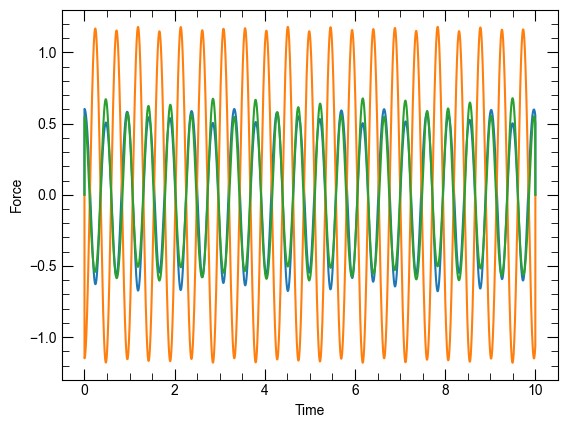

In [26]:
# plot forces over time
fig, ax = plt.subplots()
time_array = np.arange(num_steps) * dt
for i in range(num_particles):
    ax.plot(time_array, forces_traj[:, i], label=f"Force on Particle {i}")
ax.set_xlabel("Time")
ax.set_ylabel("Force")